## Loading packages

In [1]:
import torch
from torch import nn
import kagglehub
import os
import numpy as np
from glob import glob
from matplotlib import pyplot as plt
from PIL import Image

In [2]:
BATCH_SIZE = 50
device = 'cpu'
device

'cpu'

## Loading dataset

In [3]:
BASE_PATH = os.path.join(kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia"),"chest_xray")

DATASET_PATH = {}

DATASET_PATH['train'] = os.path.join(BASE_PATH, 'train')
DATASET_PATH['test'] = os.path.join(BASE_PATH, 'test')
DATASET_PATH['val'] = os.path.join(BASE_PATH, 'val')

LABELS = {0:'NORMAL',
          1:'PNEUMONIA'}

IMAGE_SIZE = (128, 128)

def load_dataset(dataset_name):
  X = []
  Y = []
  for (label_encoding, label) in LABELS.items():
    tmp = glob(os.path.join(DATASET_PATH[dataset_name], label, "*.jpeg"))
    for img_path in tmp:
      img = Image.open(img_path).resize(IMAGE_SIZE).convert('L')
      img_array = np.array(img)

      #img_array = np.stack([img_array, img_array, img_array], axis=-1)
      X.append(img_array)
      Y.append(label_encoding)

  X = np.array(X)
  Y = np.array(Y)
  return X, Y


X_train, y_train = load_dataset('train')
X_test, y_test = load_dataset('test')
X_val, y_val = load_dataset('val')

X_train.shape, y_train.shape, X_test.shape, y_test.shape, X_val.shape, y_val.shape

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.


((5216, 128, 128), (5216,), (624, 128, 128), (624,), (16, 128, 128), (16,))

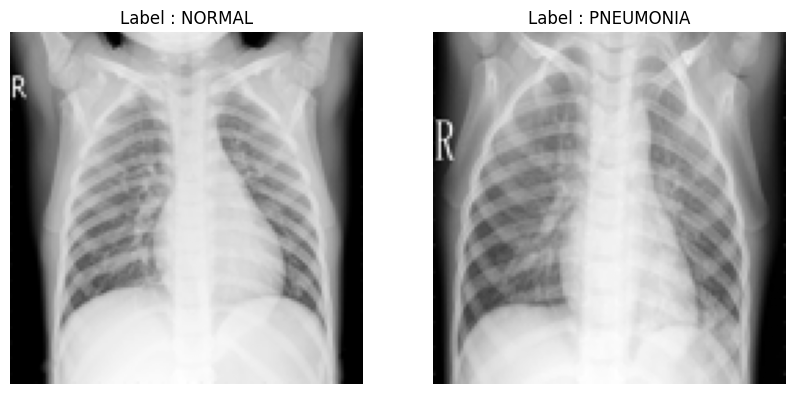

In [4]:
plt.figure(figsize=[10,7])
plt.subplot(1,2,1)
plt.imshow(X_val[0], cmap="gray")
plt.axis('off')
plt.title(f"Label : {LABELS[y_val[0]]}")

plt.subplot(1,2,2)
plt.imshow(X_val[-1], cmap="gray")
plt.axis('off')
plt.title(f"Label : {LABELS[y_val[-1]]}")

plt.show()

In [5]:
X_train = torch.tensor(X_train, device=device)
X_test = torch.tensor(X_test, device=device)
X_val = torch.tensor(X_val, device=device)
y_train = torch.tensor(y_train, device=device, dtype=torch.float32)
y_test = torch.tensor(y_test, device=device, dtype=torch.float32)
y_val = torch.tensor(y_val, device=device, dtype=torch.float32)

X_train.shape, y_train.shape, X_test.shape, y_test.shape, X_val.shape, y_val.shape

(torch.Size([5216, 128, 128]),
 torch.Size([5216]),
 torch.Size([624, 128, 128]),
 torch.Size([624]),
 torch.Size([16, 128, 128]),
 torch.Size([16]))

In [6]:
X_train.min(), X_train.max(), X_test.min(), X_test.max(), X_val.min(), X_val.max()

(tensor(0, dtype=torch.uint8),
 tensor(255, dtype=torch.uint8),
 tensor(0, dtype=torch.uint8),
 tensor(255, dtype=torch.uint8),
 tensor(0, dtype=torch.uint8),
 tensor(251, dtype=torch.uint8))

In [7]:
def scale_img(image_set):
  return (image_set - image_set.min())/(image_set.max() - image_set.min())

X_train = scale_img(X_train)
X_test = scale_img(X_test)
X_val = scale_img(X_val)

X_train.min(), X_train.max(), X_test.min(), X_test.max(), X_val.min(), X_val.max()

(tensor(0.), tensor(1.), tensor(0.), tensor(1.), tensor(0.), tensor(1.))

In [8]:
## Because PyTorch expectation image shape is (batch, channel, height, width)
X_train = X_train.reshape(5216, 1, 128, 128)
X_test = X_test.reshape(624,1,128,128)
X_val = X_val.reshape(16,1,128,128)

In [9]:
trainset = torch.utils.data.TensorDataset(X_train, y_train)

In [10]:
NUM_WORKERS = 0
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

## Convolutional Neural Network

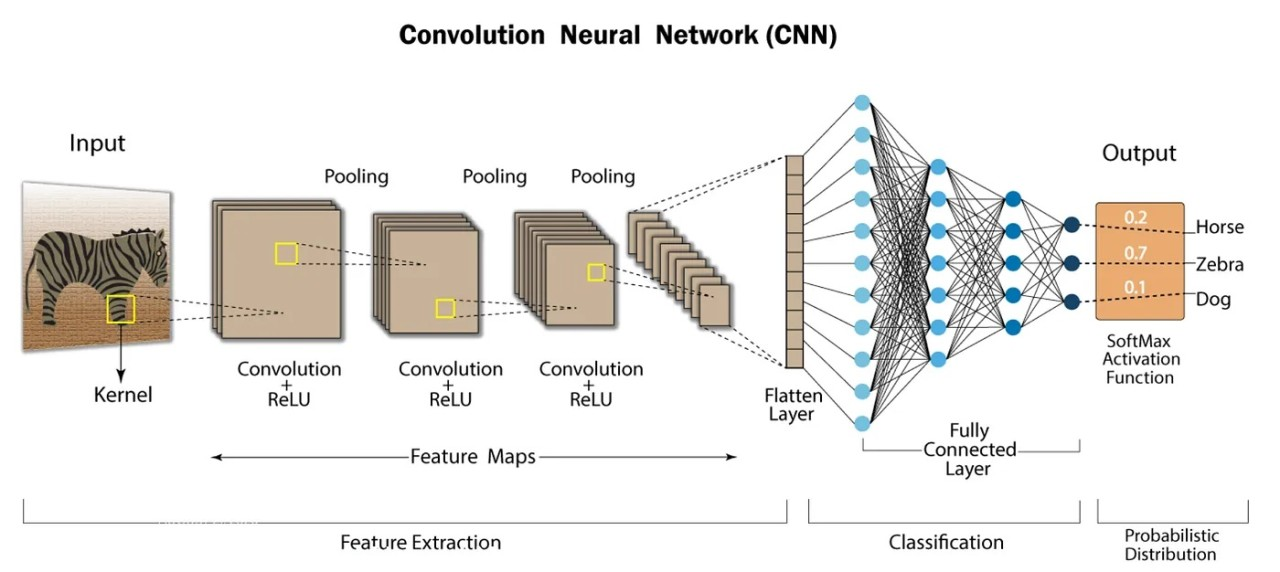

### Build a CNN

In [11]:
from typing import OrderedDict

class ConvNeuralNetwork(nn.Module):
  def __init__(self):
     super().__init__()

     self.features = nn.Sequential(
         OrderedDict([
             # Conv Layer 1
             ("conv1", nn.Conv2d(1,64,kernel_size=(11,11), stride=(4,4), padding=(2,2))),
             ("relu1", nn.ReLU(inplace=True)),
             ("pool1", nn.MaxPool2d(3, 2, 0, 1, ceil_mode=False)),
             # Conv Layer 2
             ("conv2", nn.Conv2d(64,192,(5,5),(1,1), (2,2))),
             ("relu2", nn.ReLU(inplace=True)),
             ("pool2", nn.MaxPool2d(3, 2, 0, 1, ceil_mode=False)),
             # Conv Layer 3
             ("conv3", nn.Conv2d(192,384,(3,3),(1,1), (1,1))),
             ("relu3", nn.ReLU(inplace=True)),
             ("pool3", nn.MaxPool2d(3, 2, 0, 1, ceil_mode=False)),
         ])
     )
     self.flatten = nn.Flatten()
     self.classifier = nn.Sequential(
         OrderedDict([
           # Fully connected Layer
          ("dropout1", nn.Dropout()),
          ("fc1", nn.Linear(384*3*3, 4096)),
          ("relu_fc1", nn.ReLU()),
          ("dropout2", nn.Dropout()),
          ("fc2", nn.Linear(4096, 4096)),
          ("relu_fc2", nn.ReLU()),
          ("fc3", nn.Linear(4096, 10)),
          ("relu_fc3", nn.ReLU()),
          ("fc_final", nn.Linear(10, 1))
        ])
     )

  def forward(self, X):
    X = self.features(X)
    X = self.flatten(X)
    return self.classifier(X)

model1 = ConvNeuralNetwork()
model1

ConvNeuralNetwork(
  (features): Sequential(
    (conv1): Conv2d(1, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (relu1): ReLU(inplace=True)
    (pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (relu2): ReLU(inplace=True)
    (pool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv3): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu3): ReLU(inplace=True)
    (pool3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (classifier): Sequential(
    (dropout1): Dropout(p=0.5, inplace=False)
    (fc1): Linear(in_features=3456, out_features=4096, bias=True)
    (relu_fc1): ReLU()
    (dropout2): Dropout(p=0.5, inplace=False)
    (fc2): Linear(in_features=4096, out_features=4096, bias=True)
    (relu_fc2): ReLU()
    (f

### Optimizer and loss function

In [12]:
class EarlyStoppong:

  def __init__(self, patience=5, metric="valid_acc", threshold=0):
    self.patience = patience
    self.metric = metric
    self.threshold = threshold

    self.checking_table = []
    self.results = False
    self.curr = torch.inf
    self.prev = torch.inf

  def __call__(self, history):

    def check_accuracy(prev, curr, threshold):
      return (prev-curr) >= threshold

    def check_loss(prev, curr, threshold):
      return (prev-curr) <= threshold

    metrics_values = history[self.metric]

    self.curr = metrics_values[-1]
    if len(metrics_values)==1:
      self.prev = metrics_values[-1]
    else:
      self.prev = metrics_values[-2]

    if len(self.checking_table) == self.patience:
      if sum(self.checking_table) == self.patience:
        self.results=True
      self.checking_table = []

    else:
      if "acc" in self.metric:
        if check_accuracy(self.prev, self.curr, self.threshold):
          self.checking_table.append(0)
        else:
          self.checking_table.append(1)
      if "loss" in self.metric:
        if check_loss(self.prev, self.curr, self.threshold):
          self.checking_table.append(0)
        else:
          self.checking_table.append(1)

    return self.results

In [13]:
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter)

def plot_results(metrics, title=None, ylabel=None, ylim=None, metric_name=None, color=None, epoch_nb=100):

    fig, ax = plt.subplots(figsize=(15, 4))

    if not (isinstance(metric_name, list) or isinstance(metric_name, tuple)):
        metrics = [metrics,]
        metric_name = [metric_name,]

    for idx, metric in enumerate(metrics):
        ax.plot(metric, color=color[idx])

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xlim([0, epoch_nb])
    plt.ylim(ylim)
    # Tailor x-axis tick marks
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    plt.grid(True)
    plt.legend(metric_name)
    plt.show()
    plt.close()

In [14]:
lr = 0.001
alpha = 0.01
update_lr = lambda epoch : lr/(1+alpha*epoch)

early_stopping = EarlyStoppong(metric="train_acc")
loss_func = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model1.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, update_lr)

In [15]:
def compute_accuracy(y_hat, y_true):
    y_hat = y_hat.squeeze()
    y_true = y_true.squeeze()

    predictions = (y_hat >= 0)

    accuracy = (predictions == y_true).float().mean()

    return accuracy.item()

### Training

In [16]:
def training_loop(model, trainset, loss_func, optimizer, scheduler=None, validset=None, monitoring = None, num_epochs=100):
  hist={
      'train_loss':[],
      'train_acc':[]
  }

  if validset != None:
    hist["valid_acc"] = []
    hist["valid_loss"] = []
    X_val, Y_val = validset

  for epoch in range(num_epochs):
    ## Set the model to train mode
    model.train()
    epoch_loss = 0.0
    epoch_acc = 0.0
    num_batches = len(trainset)
    for X_train, Y_train in trainset:
      ## initialize the gradien to zero
      optimizer.zero_grad()
      ## Forward pass
      Y_train_hat = model(X_train).squeeze()
      ## Compute loss
      loss = loss_func(Y_train_hat, Y_train)
      ## Backward
      loss.backward()
      optimizer.step()

      epoch_loss += loss.item()
      epoch_acc += compute_accuracy(Y_train_hat, Y_train)

    ## Store train metrics
    hist["train_loss"].append(epoch_loss/num_batches)
    hist["train_acc"].append(epoch_acc/num_batches)

    if scheduler != None:
      if epoch%5==0:
        scheduler.step()
    ## Print training progress
    digit = len(str(num_epochs))
    str_epoch = f"{str(epoch+1):{digit}s}"
    print(f"Epoch : [{str_epoch}/{num_epochs}]-------------------------------------")
    print(f"\t-> Trainset : \n *Loss={hist['train_loss'][-1]}\t *Acc={hist['train_acc'][-1]}")
    if validset != None:
      model.eval()
      with torch.inference_mode():
        Y_val_hat = model(X_val).squeeze()
        loss = loss_func(Y_val_hat, Y_val)
        hist["valid_loss"].append(loss.item())
        hist["valid_acc"].append(compute_accuracy(Y_val_hat, Y_val))
        print(f"\t-> Validset : \n *Loss={hist['valid_loss'][-1]}\t *Acc={hist['valid_acc'][-1]}")

    if monitoring != None:
      if monitoring(hist):
        break
  return hist


In [ ]:
EPOCHS = 20
hist = training_loop(model1, trainloader, loss_func, optimizer, scheduler, (X_test, y_test), early_stopping, EPOCHS)

Epoch : [1 /20]-------------------------------------
	-> Trainset : 
 *Loss=0.708368802638281	 *Acc=0.2595000000936644
	-> Validset : 
 *Loss=0.6962116956710815	 *Acc=0.31089743971824646
Epoch : [2 /20]-------------------------------------
	-> Trainset : 
 *Loss=0.6704849424816314	 *Acc=0.716142855939411
	-> Validset : 
 *Loss=0.676534116268158	 *Acc=0.625
Epoch : [3 /20]-------------------------------------
	-> Trainset : 
 *Loss=0.6092209739344461	 *Acc=0.743761906737373
	-> Validset : 
 *Loss=0.6866289973258972	 *Acc=0.625
Epoch : [4 /20]-------------------------------------
	-> Trainset : 
 *Loss=0.5865146179993947	 *Acc=0.7433571435156323
	-> Validset : 
 *Loss=0.7008821368217468	 *Acc=0.625


In [ ]:
plot_results([ hist['train_loss'], hist['valid_loss'] ],
            ylabel="Loss",
            metric_name=["Training Loss", "Validation Loss"],
            color=["g", "b"], epoch_nb=EPOCHS)
plot_results([ hist['train_acc'], hist['valid_acc'] ],
            ylabel="Accuracy",
            metric_name=["Training Accuray", "Validation Accuracy"],
            color=["g", "b"], epoch_nb=EPOCHS)

In [ ]:
torch.sigmoid(model1(X_val))